# Setup and Paradigm Categorization

Following the literature bias analysis conducted on the Neurosynth database, this notebook performs an equivalent investigation using the BrainMap database.

Because BrainMap relies on manually curated experimental "Paradigm Classes" rather than automated text-mining of abstracts, we first explicitly map a predefined list of BrainMap paradigms to our three target cognitive domains: Affect, Valuation, and Social cognition. This allows us to standardly compare study distributions across both databases.

In [1]:
from tqdm import tqdm
import joblib
from pathlib import Path
import nibabel as nib
import numpy as np
import nilearn.plotting as nplt
from tqdm import trange
import matplotlib.pyplot as plt
import warnings
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.image import coord_transform
import numpy as np
from nibabel.affines import apply_affine
from matplotlib_venn import venn3
from nilearn.image import coord_transform
import seaborn as sns
import matplotlib.transforms as transforms

plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
warnings.filterwarnings("ignore", category=FutureWarning)

# Path Settings
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')

DATASET_FILE = DATA_PATH / 'brainmap_data/brainmap.dataset.pkl'

DATASET = joblib.load(DATASET_FILE)

AFFECT_PARADIGM_LIST = ['AffectivePictures', 'EmotionInduction', 'StroopEmotional', 'EmotionalBodyLanguagePerception',
                        'InducedPanic', 'AffectiveWords', 'TraumaRecall', 'PainMonitorDiscrimination']
VALUATION_PARADIGM_LIST = ['Gambling', 'DelayDiscounting', 'Reward', 'Taste', 'HungerSatiety', 'DrugChallenge',
                           'SexualArousalGratification', ]
SOCIAL_PARADIGM_LIST = ['TheoryofMind', 'FaceMonitorDiscrimination', 'Deception', 'CompetitionCooperation',
                        'SelfReflection', ]
category_color_mapping_dict = {'Affect': '#ff0000', 'Social': '#0051ff', 'Valuation': '#ffef00', }
PARADIGM_LIST = list(set(AFFECT_PARADIGM_LIST + VALUATION_PARADIGM_LIST + SOCIAL_PARADIGM_LIST))
PARADIGM_MAP_NAME_DICT = {
    'Reward': 'reward',
    'FaceMonitorDiscrimination': 'face monitor/discrimination',
    'EmotionalBodyLanguagePerception': 'emotional body language perception',
    'DelayDiscounting': 'delay discounting',
    'DrugChallenge': 'drug challenge',
    'CompetitionCooperation': 'competition/cooperation',
    'AffectiveWords': 'affective words',
    'HungerSatiety': 'hunger/satiety',
    'PainMonitorDiscrimination': 'pain monitor/discrimination',
    'SelfReflection': 'self-reflection',
    'EmotionInduction': 'emotion induction',
    'Taste': 'taste',
    'TraumaRecall': 'trauma recall',
    'ClassicalConditioning': 'classical conditioning',
    'InducedPanic': 'induced panic',
    'FigurativeLanguage': 'figurative language',
    'TheoryofMind': 'theory of mind',
    'Deception': 'deception',
    'AffectivePictures': 'affective pictures',
    'Gambling': 'gambling',
    'StroopEmotional': 'stroop-emotional',
    'SexualArousalGratification': 'sexual arousal/gratification'
}

PARADIGM_MAP_CATEGORY_DICT = {}
for paradigm in AFFECT_PARADIGM_LIST:
    PARADIGM_MAP_CATEGORY_DICT[paradigm] = 'Affect'
for paradigm in VALUATION_PARADIGM_LIST:
    PARADIGM_MAP_CATEGORY_DICT[paradigm] = 'Valuation'
for paradigm in SOCIAL_PARADIGM_LIST:
    PARADIGM_MAP_CATEGORY_DICT[paradigm] = 'Social'


In [2]:

exp_id_map_paradigm_list_dict = joblib.load(DATA_PATH / 'brainmap_data/exp_id_map_paradigm.dict.pkl')
coords_df = DATASET.coordinates.copy()
for exp_id, paradigm_list in tqdm(exp_id_map_paradigm_list_dict.items()):
    for paradigm in paradigm_list:
        coords_df.loc[coords_df['id'] == exp_id, paradigm] = 1

100%|██████████| 7718/7718 [01:13<00:00, 105.19it/s]


# Spatial Coordinate Alignment

To determine whether a specific BrainMap study targeted our region of interest, we must project the raw activation coordinates from the database into our analytical space. We convert the MNI coordinates into voxel indices and construct boolean masks (`is_in_NeurosynthROI` and `is_in_BrainMapROI`). This precisely identifies which individual experimental contrasts reported peak activations within the boundaries of our VMPFC subregions.

In [3]:
roi_image = nib.load(RESULTS_PATH / 'nii/K3.nii.gz')
mask_data = roi_image.get_fdata() > 0
coords_df[["x_idx", "y_idx", "z_idx"]] = np.rint(
    apply_affine(np.linalg.inv(roi_image.affine), coords_df[["x", "y", "z"]])).astype(int)
coords_df = coords_df[
    (coords_df["x_idx"] >= 0) & (coords_df["x_idx"] < roi_image.shape[0]) &
    (coords_df["y_idx"] >= 0) & (coords_df["y_idx"] < roi_image.shape[1]) &
    (coords_df["z_idx"] >= 0) & (coords_df["z_idx"] < roi_image.shape[2])
    ].copy()

coords_df["is_in_NeurosynthROI"] = mask_data[
    coords_df["x_idx"].values,
    coords_df["y_idx"].values,
    coords_df["z_idx"].values
]

roi_image = nib.load(RESULTS_PATH / 'nii/BrainMap_K3.nii.gz')
mask_data = roi_image.get_fdata() > 0
coords_df[["x_idx", "y_idx", "z_idx"]] = np.rint(
    apply_affine(np.linalg.inv(roi_image.affine), coords_df[["x", "y", "z"]])).astype(int)
coords_df = coords_df[
    (coords_df["x_idx"] >= 0) & (coords_df["x_idx"] < roi_image.shape[0]) &
    (coords_df["y_idx"] >= 0) & (coords_df["y_idx"] < roi_image.shape[1]) &
    (coords_df["z_idx"] >= 0) & (coords_df["z_idx"] < roi_image.shape[2])
    ].copy()
coords_df["is_in_BrainMapROI"] = mask_data[
    coords_df["x_idx"].values,
    coords_df["y_idx"].values,
    coords_df["z_idx"].values
]

In [4]:
coords_df['has_task'] = coords_df[PARADIGM_LIST].sum(axis=1) > 0
coords_df['is_social_task'] = coords_df[SOCIAL_PARADIGM_LIST].sum(axis=1) > 0
coords_df['is_valuation_task'] = coords_df[VALUATION_PARADIGM_LIST].sum(axis=1) > 0
coords_df['is_affect_task'] = coords_df[AFFECT_PARADIGM_LIST].sum(axis=1) > 0

# Visualizing Paradigm Overlap in BrainMap

We generate proportional Venn diagrams to visualize the intersection of BrainMap studies across the three categorized functional domains.

Similar to our previous analysis, we contrast two levels of data:
* **Left:** The paradigm distribution across all neuroimaging studies in the BrainMap database.
* **Right:** The paradigm distribution filtered strictly for studies reporting activations within the VMPFC.

This confirms whether the functional domain overlaps observed in the text-based Neurosynth database are reliably reproduced using BrainMap's manual paradigm annotations.

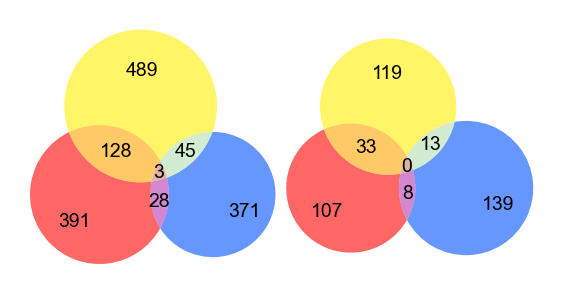

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4.5))

ax = axes[0]

v = venn3(
    subsets=[
        set(coords_df.query('is_social_task')['study_id'].unique()),
        set(coords_df.query('is_valuation_task')['study_id'].unique()),
        set(coords_df.query('is_affect_task')['study_id'].unique()),
    ],
    set_labels=[''] * 3,
    set_colors=category_color_mapping_dict.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(14)
ax.invert_yaxis()

ax = axes[1]
v = venn3(
    subsets=[
        set(coords_df.query('is_social_task & is_in_BrainMapROI')['study_id'].unique()),
        set(coords_df.query('is_valuation_task & is_in_BrainMapROI')['study_id'].unique()),
        set(coords_df.query('is_affect_task & is_in_BrainMapROI')['study_id'].unique()),
    ],
    set_labels=[''] * 3,
    set_colors=category_color_mapping_dict.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(14)
ax.invert_yaxis()

plt.subplots_adjust(wspace=-0.1, hspace=0)

fig.savefig(PLOTS_PATH / 'bias/BrainMap_domain.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'bias/BrainMap_domain.svg', **PLOT_KWARGS_DICT)
fig

In [6]:


plot_data_list = []
for paradigm in PARADIGM_LIST:
    VMPFC_study_num = coords_df.query(f'{paradigm} == 1').query('is_in_NeurosynthROI')['study_id'].nunique()
    whole_brain_study_num = coords_df.query(f'{paradigm} == 1')['study_id'].nunique()
    plot_data_list.append(
        dict(paradigm=paradigm, whole_brain_study_num=whole_brain_study_num, VMPFC_study_num=VMPFC_study_num))
neurosynth_plot_data = pd.DataFrame(plot_data_list)
neurosynth_plot_data = neurosynth_plot_data.sort_values(by='VMPFC_study_num', ascending=False)
neurosynth_plot_data['category'] = neurosynth_plot_data['paradigm'].map(PARADIGM_MAP_CATEGORY_DICT)

plot_data_list = []
for paradigm in PARADIGM_LIST:
    VMPFC_study_num = coords_df.query(f'{paradigm} == 1').query('is_in_BrainMapROI')['study_id'].nunique()
    whole_brain_study_num = coords_df.query(f'{paradigm} == 1')['study_id'].nunique()
    plot_data_list.append(
        dict(paradigm=paradigm, whole_brain_study_num=whole_brain_study_num, VMPFC_study_num=VMPFC_study_num))
brainmap_plot_data = pd.DataFrame(plot_data_list)
brainmap_plot_data = brainmap_plot_data.sort_values(by='VMPFC_study_num', ascending=False)
brainmap_plot_data['category'] = brainmap_plot_data['paradigm'].map(PARADIGM_MAP_CATEGORY_DICT)

fig, ax = plt.subplots(figsize=(7, 6))

sns.barplot(data=neurosynth_plot_data, x='whole_brain_study_num', y='paradigm', width=0.8, color='gray', alpha=0.2,
            ax=ax)

shift_up = transforms.ScaledTranslation(0, -0.05, ax.figure.dpi_scale_trans)
sns.pointplot(data=neurosynth_plot_data, x='VMPFC_study_num', y='paradigm',
              hue='category', palette=category_color_mapping_dict, ax=ax,
              markers='^', linestyles='none', ms=4, mew=0.3, mec='black',
              transform=ax.transData + shift_up)

shift_down = transforms.ScaledTranslation(0, 0.05, ax.figure.dpi_scale_trans)
sns.pointplot(data=neurosynth_plot_data, x='VMPFC_study_num', y='paradigm',
              hue='category', palette=category_color_mapping_dict, ax=ax,
              markers='o', linestyles='none', ms=3, mew=0.3, mec='black',
              transform=ax.transData + shift_down)

ax.set_yticks(range(len(neurosynth_plot_data)))
ax.set_yticklabels(neurosynth_plot_data['paradigm'].map(PARADIGM_MAP_NAME_DICT), fontsize=12)

print(
    f"Neurosynth:  {neurosynth_plot_data['VMPFC_study_num'].max() / coords_df.query('is_in_NeurosynthROI')['study_id'].nunique():.2%}")
print(
    f"BrainMap:  {brainmap_plot_data['VMPFC_study_num'].max() / coords_df.query('is_in_BrainMapROI')['study_id'].nunique():.2%}")

ax.set_xlabel('Number of studies', fontsize=15)
ax.set_ylabel('')
ax.set_xlim(-30, 400)
ax.get_legend().remove()
ax.set_ylim(len(neurosynth_plot_data), -1.5, )
fig.tight_layout()

fig.savefig(PLOTS_PATH / 'bias/BrainMap_task.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'bias/BrainMap_task.svg', **PLOT_KWARGS_DICT)

Neurosynth:  13.20%
BrainMap:  13.49%
